In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob 
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
# import joblib # Would be needed if you had saved IBM scalers


In [54]:

# --- 1. Define the LSTM Model Class (Copy from your original notebook) ---
class StockPredictorLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim, dropout_prob=0.2):
        super(StockPredictorLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout_prob if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out


In [55]:

# --- 2. Define Model Hyperparameters and Feature/Target Lists (Must match IBM training) ---
FEATURES_LIST = ['Open', 'High', 'Low', 'Volume', 'SMA_20', 'Volatility', 'Price_Change']
TARGET_COL = 'Close'

INPUT_DIM = len(FEATURES_LIST) # Should be 7 based on your IBM notebook
HIDDEN_DIM = 64
NUM_LAYERS = 2
OUTPUT_DIM = 1
DROPOUT = 0.2
SEQ_LENGTH = 60 # Must be same as IBM training


In [56]:

# --- 3. Load and Prepare GOOGL Data from CSVs ---
print("Loading data from CSVs...")
csv_files = glob.glob('stock-time-series-20050101-to-20171231/*.csv')
if not csv_files:
    print("Error: No CSV files found in the specified directory.")
    exit()
    
df_list = [pd.read_csv(file) for file in csv_files]
combined_df = pd.concat(df_list, ignore_index=True)

combined_df['Date'] = pd.to_datetime(combined_df['Date'])
combined_df = combined_df.sort_values('Date').reset_index(drop=True)
combined_df.ffill(inplace=True) # Forward fill missing values globally first

GOOGL_df_raw = combined_df[combined_df['Name'] == 'GOOGL'].copy()
if GOOGL_df_raw.empty:
    print("Error: No data found for GOOGL in the combined dataframe.")
    exit()

GOOGL_df_raw['Date'] = pd.to_datetime(GOOGL_df_raw['Date'])
GOOGL_df_raw = GOOGL_df_raw.sort_values('Date').reset_index(drop=True)
print(f"Loaded GOOGL data. Shape: {GOOGL_df_raw.shape}")


Loading data from CSVs...
Loaded GOOGL data. Shape: (6289, 7)


In [57]:

# --- 4. Feature Engineering for GOOGL (Same as IBM) ---
GOOGL_df = GOOGL_df_raw.copy()
GOOGL_df['SMA_20'] = GOOGL_df['Close'].rolling(window=20).mean()
GOOGL_df['Volatility'] = GOOGL_df['Close'].rolling(window=20).std()
GOOGL_df['Price_Change'] = GOOGL_df['Close'].pct_change()

# Handle NaNs created by rolling functions/pct_change
# Crucial: Do this after calculating indicators
GOOGL_df.bfill(inplace=True) # Backward fill first to handle initial NaNs if possible
GOOGL_df.ffill(inplace=True) # Then forward fill any remaining

# Check if we still have enough data after NaN handling and for sequence creation
if len(GOOGL_df) < SEQ_LENGTH + 1: # +1 because we predict the next step
    print(f"Error: Not enough data for GOOGL after preprocessing for SEQ_LENGTH={SEQ_LENGTH}.")
    exit()


In [58]:

# --- 5. Scaling GOOGL Data ---
# Since we likely don't have IBM's scalers, we'll fit new ones on GOOGL data.
# For a fair evaluation of the IBM model on GOOGL, we should conceptually
# split GOOGL data, fit scalers on a "train" part, and predict on a "test" part.

# Let's define a split for GOOGL data (e.g., 80% for fitting scalers, 20% for prediction)
# This split is ONLY for fitting the scalers, not for retraining the LSTM model.
n_googl = len(GOOGL_df)
fit_size_googl = int(n_googl * 0.80) # Use 80% to fit scalers

googl_fit_df = GOOGL_df[:fit_size_googl]
googl_pred_df = GOOGL_df[fit_size_googl:] # We will make predictions on this part

if len(googl_pred_df) < SEQ_LENGTH +1:
    print(f"Warning: The prediction set for GOOGL is very small (length {len(googl_pred_df)}). "
          f"Consider using a larger dataset or a smaller percentage for fitting scalers if this is for robust evaluation.")
    # If it's too small to even form one sequence for prediction, we might need to adjust.
    # For simplicity here, we'll proceed, but in a real scenario, ensure googl_pred_df is adequate.

# Scaler for features (fitted on GOOGL's "fit" data)
scaler_features_googl = MinMaxScaler(feature_range=(0, 1))
# Fit on the feature data from the fitting portion of GOOGL
googl_fit_df_features_scaled = scaler_features_googl.fit_transform(googl_fit_df[FEATURES_LIST])
# Transform the prediction portion of GOOGL features
X_googl_pred_features_scaled = scaler_features_googl.transform(googl_pred_df[FEATURES_LIST])


# Scaler for target (fitted on GOOGL's "fit" data)
scaler_target_googl = MinMaxScaler(feature_range=(0, 1))
# Fit on the target data from the fitting portion of GOOGL
googl_fit_df_target_scaled = scaler_target_googl.fit_transform(googl_fit_df[[TARGET_COL]])
# Transform the prediction portion of GOOGL target (for evaluation actuals)
y_googl_pred_target_scaled_actual = scaler_target_googl.transform(googl_pred_df[[TARGET_COL]])



In [59]:

# --- 6. Create Sequences for GOOGL Prediction Data ---
def create_sequences(X_scaled_features, y_scaled_target, seq_length, num_features):
    xs, ys_actual = [], []
    if len(X_scaled_features) <= seq_length:
        print("Warning: Data length for creating sequences is too short.")
        return np.array(xs), np.array(ys_actual) # Return empty arrays

    for i in range(len(X_scaled_features) - seq_length):
        xs.append(X_scaled_features[i:(i + seq_length)])
        ys_actual.append(y_scaled_target[i + seq_length])
        
    X_seq_np = np.array(xs)
    y_seq_actual_np = np.array(ys_actual)
    
    # Reshape X for LSTM: (samples, seq_length, num_features)
    # This was missing in your original create_sequences if it was for single feature target
    if X_seq_np.ndim == 2 and num_features == 1: # If X_scaled_features was 1D (e.g. only 'Close' for X)
         X_seq_np = X_seq_np.reshape(X_seq_np.shape[0], X_seq_np.shape[1], 1)
    elif X_seq_np.ndim == 3: # If X_scaled_features was already (len, num_features_per_step)
        # This should be the case here since X_googl_pred_features_scaled is (N, num_features=7)
        # and xs.append makes it (seq_length, num_features)
        pass # Shape should already be (num_samples, seq_length, num_features)
    else:
        print(f"Unexpected shape for X_seq_np: {X_seq_np.shape}. Trying to reshape assuming num_features={num_features}")
        if X_seq_np.shape[0] > 0 :
             X_seq_np = X_seq_np.reshape(X_seq_np.shape[0], seq_length, num_features)


    return X_seq_np, y_seq_actual_np

X_googl_seq, y_googl_seq_scaled_actuals = create_sequences(
    X_googl_pred_features_scaled,
    y_googl_pred_target_scaled_actual, # Pass the scaled actual targets for the prediction set
    SEQ_LENGTH,
    INPUT_DIM # num_features
)

if X_googl_seq.shape[0] == 0:
    print("Error: No sequences created for GOOGL prediction. Check data length for the prediction period and SEQ_LENGTH.")
    exit()

X_googl_tensor = torch.FloatTensor(X_googl_seq)
# y_googl_tensor_scaled_actuals is already a numpy array of scaled targets, can convert to tensor if needed for loss later
# For now, we need its unscaled version for evaluation.

print(f"\nGOOGL Data Prepared for Prediction:")
print(f"X_googl_tensor shape: {X_googl_tensor.shape}")
print(f"y_googl_seq_scaled_actuals (scaled ground truth targets) shape: {y_googl_seq_scaled_actuals.shape}")




GOOGL Data Prepared for Prediction:
X_googl_tensor shape: torch.Size([1198, 60, 7])
y_googl_seq_scaled_actuals (scaled ground truth targets) shape: (1198, 1)


In [60]:

# --- 7. Instantiate the Model and Load Weights ---
model_googl = StockPredictorLSTM(INPUT_DIM, HIDDEN_DIM, NUM_LAYERS, OUTPUT_DIM, DROPOUT)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_googl.to(device)

model_path = 'stock_predictor_lstm.pth' # Make sure this path is correct
try:
    model_googl.load_state_dict(torch.load(model_path, map_location=device))
    print(f"\nModel weights (trained on IBM) loaded successfully from {model_path}")
except Exception as e:
    print(f"Error loading model weights: {e}")
    exit()

model_googl.eval()



Model weights (trained on IBM) loaded successfully from stock_predictor_lstm.pth


StockPredictorLSTM(
  (lstm): LSTM(7, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

In [61]:

# --- 8. Make Predictions on GOOGL Data ---
X_googl_tensor_dev = X_googl_tensor.to(device)

with torch.no_grad():
    predicted_prices_scaled_googl = model_googl(X_googl_tensor_dev).cpu().numpy()

# Inverse transform the predictions using GOOGL's target scaler
predicted_prices_actual_googl = scaler_target_googl.inverse_transform(predicted_prices_scaled_googl)

# Get original actual prices for the prediction period for comparison
# These correspond to the y_googl_seq_scaled_actuals
# The dates are from googl_pred_df, starting from SEQ_LENGTH index into it.
googl_dates_for_eval = googl_pred_df.index[SEQ_LENGTH : SEQ_LENGTH + len(predicted_prices_actual_googl)]
googl_original_actual_prices_for_eval = googl_pred_df[TARGET_COL].iloc[SEQ_LENGTH : SEQ_LENGTH + len(predicted_prices_actual_googl)].values


print(f"\nSample GOOGL Predictions (Actual Price):")
for i in range(min(5, len(predicted_prices_actual_googl))):
    date_str = GOOGL_df.loc[googl_dates_for_eval[i], 'Date'].strftime('%Y-%m-%d') if googl_dates_for_eval[i] < len(GOOGL_df) else "N/A"
    print(f"Date: {date_str}, Predicted: {predicted_prices_actual_googl[i][0]:.2f}, Actual: {googl_original_actual_prices_for_eval[i]:.2f}")




Sample GOOGL Predictions (Actual Price):
Date: 2016-02-16, Predicted: 702.55, Actual: 717.64
Date: 2016-02-17, Predicted: 704.09, Actual: 731.97
Date: 2016-02-17, Predicted: 713.99, Actual: 731.97
Date: 2016-02-18, Predicted: 714.67, Actual: 717.51
Date: 2016-02-18, Predicted: 706.51, Actual: 717.51



--- GOOGL Prediction Evaluation Metrics (using IBM-trained model) ---
Mean Squared Error (MSE): 686.5734
Root Mean Squared Error (RMSE): 26.2025
Mean Absolute Error (MAE): 23.2546
Mean Absolute Percentage Error (MAPE) for non-zero actuals: 2.57%


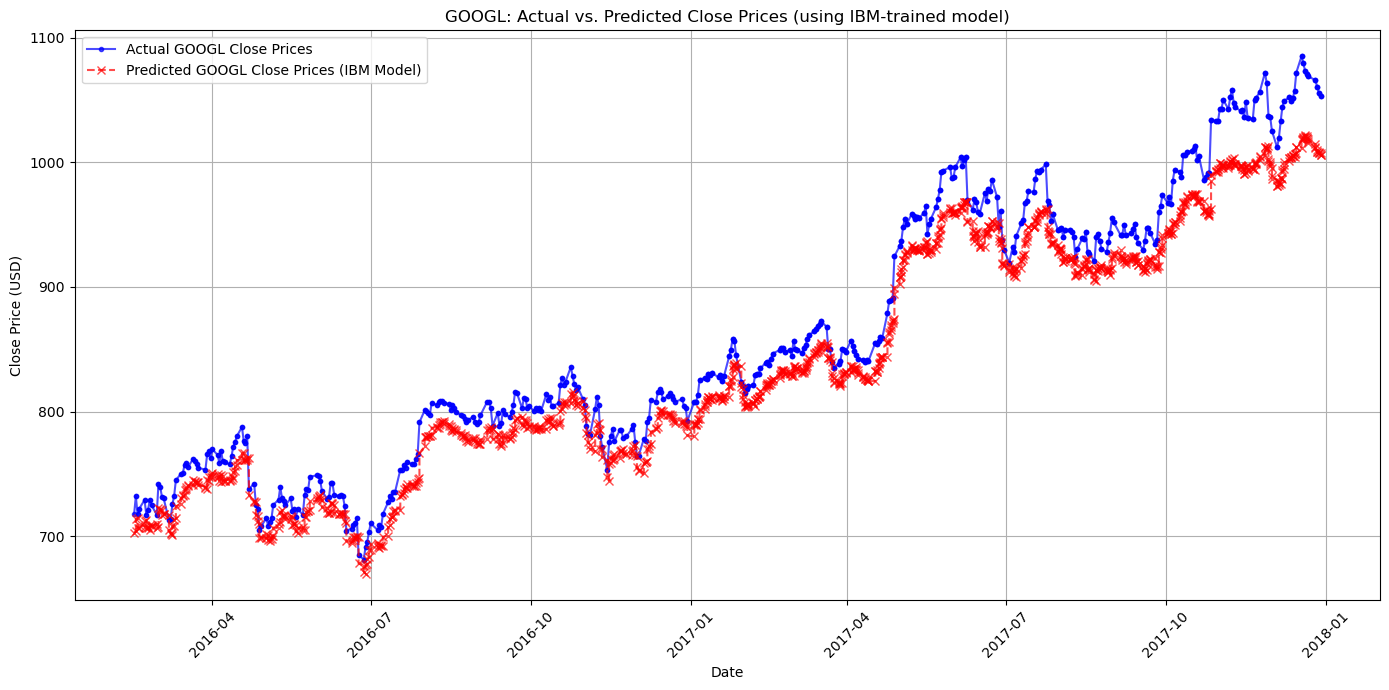

In [62]:

# --- 9. Evaluate (Optional) ---
from sklearn.metrics import mean_squared_error, mean_absolute_error

if len(predicted_prices_actual_googl.flatten()) == len(googl_original_actual_prices_for_eval):
    mse_googl = mean_squared_error(googl_original_actual_prices_for_eval, predicted_prices_actual_googl.flatten())
    rmse_googl = np.sqrt(mse_googl)
    mae_googl = mean_absolute_error(googl_original_actual_prices_for_eval, predicted_prices_actual_googl.flatten())

    print(f"\n--- GOOGL Prediction Evaluation Metrics (using IBM-trained model) ---")
    print(f"Mean Squared Error (MSE): {mse_googl:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse_googl:.4f}")
    print(f"Mean Absolute Error (MAE): {mae_googl:.4f}")

    # MAPE
    non_zero_actuals_mask_googl = googl_original_actual_prices_for_eval != 0
    if np.any(non_zero_actuals_mask_googl):
        mape_googl_nz = np.mean(np.abs((googl_original_actual_prices_for_eval[non_zero_actuals_mask_googl] - predicted_prices_actual_googl.flatten()[non_zero_actuals_mask_googl]) / googl_original_actual_prices_for_eval[non_zero_actuals_mask_googl])) * 100
        print(f"Mean Absolute Percentage Error (MAPE) for non-zero actuals: {mape_googl_nz:.2f}%")
else:
    print(f"Length mismatch: Actuals ({len(googl_original_actual_prices_for_eval)}), Predictions ({len(predicted_prices_actual_googl.flatten())}). Cannot evaluate.")


# --- 10. Plot Results ---
plt.figure(figsize=(14, 7))
plt.plot(GOOGL_df['Date'].iloc[googl_dates_for_eval], googl_original_actual_prices_for_eval, label='Actual GOOGL Close Prices', color='blue', marker='.', alpha=0.7)
plt.plot(GOOGL_df['Date'].iloc[googl_dates_for_eval], predicted_prices_actual_googl, label='Predicted GOOGL Close Prices (IBM Model)', color='red', linestyle='--', marker='x', alpha=0.7)
plt.title('GOOGL: Actual vs. Predicted Close Prices (using IBM-trained model)')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()